# 🎬 Does Order Matter?  
### A head-to-head comparison of FP-Growth / Apriori and PrefixSpan on MovieLens 25M

**Course:** Data Mining & Analysis

**Student**: Raissa Marques da Silva

**Dataset:** MovieLens 25M (GroupLens Research)

---

The research question for this project is simple: **on real movie-watching data, how much does the ORDER of watches matter?**

Frequent-itemset mining (Apriori, FP-Growth) treats each user's history as an **unordered basket**. It knows *what* you watched but not *when*. Sequential pattern mining (PrefixSpan) treats each history as an **ordered sequence**. It uses the full temporal information. The textbook pitch for PrefixSpan is basically *"it's like Apriori but with ordering"*. But does that ordering actually *buy* you anything on real data?

This project runs both methods head-to-head on MovieLens 25M. I defined a single asymmetry metric to quantify "does order matter for this pair of movies?", ran a next-watch prediction evaluation to see whether sequential patterns actually help downstream, and walked away with an answer that surprised me:

> **The short answer is: not the way the textbook suggests. Roughly half of the movie pairs I analyzed are strongly asymmetric in PrefixSpan, but that asymmetry turns out to be driven mostly by release-date artifacts of the MovieLens dataset itself, not by genuine narrative-sequence behavior. When I push through to the actual downstream task (predicting a user's next watch), the ordered model performs slightly *worse* than the unordered one: Apriori's Hit@10 is 0.110 while PrefixSpan's is 0.090. So on this data, the ordering information PrefixSpan extracts is real, but it points mostly at timestamp structure rather than at recommendation-relevant sequence structure. That's a negative result in the best sense of the term: it tells us something concrete about MovieLens and about when sequence mining is worth the trouble.**

## 1. Motivation

In Checkpoint 1, I explored three candidate datasets and settled on MovieLens 25M because it offered both scale (25M ratings) and the one ingredient I was most curious about: **high-resolution timestamps**. Most frequent-pattern examples work on transactional data (basket contents at checkout) where ordering doesn't apply, because items in a basket are simultaneous. Movie ratings are different: each rating has a timestamp, so we can legitimately ask whether users who rate *A* and *B* tend to rate *A* first.

In Checkpoint 2, I proposed three research questions, all variations on "run FP-Growth here, Apriori there, PrefixSpan on the side". Re-reading the final-project brief, I realized that would be exactly the kind of hodge-podge the professor warned against. So I collapsed them into one:

> **Does the temporal ordering of movie ratings contain pattern-mining signal that an unordered basket representation throws away?**

This is a head-to-head question. FP-Growth vs PrefixSpan, same data, same support threshold, and then a concrete downstream task to adjudicate the tie.

### Why this is a "real" question and not just a method comparison

PrefixSpan is strictly more expressive than FP-Growth. It sees everything FP-Growth sees and more. So if you just ask "does PrefixSpan find more patterns?", the answer is trivially yes. The interesting question is **qualitative**: does the extra information identify *structure that matters*, or does it mostly just re-derive the same co-occurrence patterns with extra bookkeeping? The answer tells us something meaningful about how people actually watch movies, and (as it turned out) about how MovieLens actually records what they watch.

## 2. Setup

The dataset is MovieLens 25M (162k users, 62k movies, 25M ratings).

In [ ]:
!pip install efficient-apriori prefixspan

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for prefixspan: filename=prefixspan-0.5.2-py3-none-any.whl size=11215 sha256=45acf3104bab8af60d7b0e2fb26d53546354865ff621134dd86251797b35cd5f
  Stored in directory: /root/.cache/pip/wheels/72/36/65/f9e2bbe4998ab4cdf6e7a015f38bdbb6925301dcf2cce34a88
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=5bdebe5566177be22dd20b66dbcf63b2b54a5e81a73a52925b31197afbfe7ee6
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
  Created wheel for extratools: filename=extratools-0.8.2.1-py3-none-any.whl size=28865 sha256=7804d6f3e8ebf8b5cbf1dbdcd86118922247cbadbd6b0fe4e073d0c460d2cd88
  Stored in directory: /root/.cache/pip/wheels/0f/ab/1f/a5cf2e0513d68e4ff783d169add0c94235bddf2bb8f3dcd581
Successfully built prefixspan docopt extratools


In [ ]:
# --- Environment & imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os, pickle
from collections import defaultdict
from itertools import permutations

# Packages beyond the course-standard stack
# efficient_apriori: a dramatically faster Apriori/FP-Growth implementation (mlxtend's was ~100x slower at our scale; see Appendix A)
# prefixspan: the external sequential-pattern mining library
from efficient_apriori import apriori
from prefixspan import PrefixSpan

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RNG = np.random.default_rng(42)

In [ ]:
# --- Data hydration ---
import requests
import zipfile

def hydrate_movielens():
    url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
    data_dir = "../data"
    zip_path = os.path.join(data_dir, "ml-25m.zip")
    extract_path = os.path.join(data_dir, "ml-25m")

    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    if not os.path.exists(zip_path):
        print("Downloading MovieLens 25M (~250MB)...")
        r = requests.get(url, stream=True)
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
        print("Download complete.")
    if not os.path.exists(extract_path):
        print("Extracting...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)
        print("Done.")

hydrate_movielens()
DATA_PATH = "../data/ml-25m/"
ratings = pd.read_csv(DATA_PATH + "ratings.csv")
movies  = pd.read_csv(DATA_PATH + "movies.csv")
print(f"Loaded: {len(ratings):,} ratings, {len(movies):,} movies, "
      f"{ratings.userId.nunique():,} users")

Download complete.
Extracting...
Done.
Loaded: 25,000,095 ratings, 62,423 movies, 162,541 users


## 3. Sampling & preprocessing

The full 25M dataset does not fit in PrefixSpan's working memory. Sequence-pattern mining scales poorly with long sequences, and some users in MovieLens have rated **thousands** of movies. I use a simple, defensible sampling protocol:

| Knob | Value | Why |
|---|---|---|
| `SAMPLE_USERS` | 10,000 | ~6% of the user base. Empirically, PrefixSpan runs in ~15 s at this scale. |
| `TOP_K_MOVIES` | 500 | Restrict to the 500 most-rated movies in the sample. Makes frequent-pattern support thresholds reach non-trivial itemsets while still including all culturally relevant titles. |
| `MAX_SEQ_LEN` | 40 | Cap each user's sequence at their 40 *earliest* ratings. Gives PrefixSpan a fair shot without letting power-users dominate runtime. |
| `MIN_USER_MOVIES` | 5 | Drop very-light users whose histories can't produce any frequent pattern of length ≥ 2. |
| `MIN_SUPPORT` | 0.05 | Any itemset/sequence must appear in ≥ 5% of users. |

I want to be honest about the tradeoff: these choices favor **interpretability over comprehensiveness**. A bigger sample or wider movie pool would surface more long-tail findings but make the core comparison harder to read. The goal of the project is a clean answer to one question, not the widest possible net.

In [ ]:
# --- Parameters ---
SAMPLE_USERS     = 10_000
TOP_K_MOVIES     = 500
MAX_SEQ_LEN      = 40
MIN_USER_MOVIES  = 5
MIN_SUPPORT      = 0.05

# --- Sample users ---
sampled = RNG.choice(ratings["userId"].unique(),
                     size=min(SAMPLE_USERS, ratings["userId"].nunique()),
                     replace=False)
r = ratings[ratings["userId"].isin(sampled)].copy()
print(f"Sampled: {len(r):,} ratings from {len(sampled):,} users")

# --- Keep top-K most-rated movies ---
movie_counts = r.groupby("movieId").size().sort_values(ascending=False)
top_movies_list = movie_counts.head(TOP_K_MOVIES).index
r = r[r["movieId"].isin(top_movies_list)]
print(f"Kept top {TOP_K_MOVIES} movies -> {len(r):,} ratings")

# --- Cap each user's sequence length (earliest MAX_SEQ_LEN ratings) ---
r = r.sort_values(["userId","timestamp"])
r["_rank"] = r.groupby("userId")["timestamp"].rank(method="first", ascending=True)
r = r[r["_rank"] <= MAX_SEQ_LEN].drop(columns="_rank")

# --- Filter out users with too few ratings ---
uc = r.groupby("userId").size()
keep = uc[uc >= MIN_USER_MOVIES].index
r = r[r["userId"].isin(keep)]

# --- Build baskets (unordered sets) and sequences (ordered lists) ---
r = r.sort_values(["userId","timestamp"])
sequences = r.groupby("userId")["movieId"].apply(list)
baskets   = sequences.apply(lambda s: tuple(set(s)))
N = len(sequences)

# Title lookup for readable output later
title_map = dict(zip(movies.movieId, movies.title))

print(f"\nFinal: {N:,} users, "
      f"{len(set().union(*baskets)):,} unique movies, "
      f"mean seq length = {sequences.apply(len).mean():.1f}")

Sampled: 1,553,687 ratings from 10,000 users
Kept top 500 movies -> 679,216 ratings

Final: 9,781 users, 500 unique movies, mean seq length = 31.9


In [ ]:
# --- A peek at what a basket vs a sequence looks like for the same user ---
uid = sequences.index[0]
seq = sequences.iloc[0]
bsk = set(seq)
print(f"User {uid} rated {len(seq)} movies (showing first 8).")
print(f"\nAs a SEQUENCE (what PrefixSpan sees):")
for i, m in enumerate(seq[:8]):
    print(f"  step {i+1}: {title_map.get(m, m)[:70]}")
print(f"\nAs a BASKET (what FP-Growth/Apriori sees):")
for m in list(bsk)[:8]:
    print(f"  {title_map.get(m, m)[:70]}")
print("\nThe two representations contain the same movies, but only the sequence "
      "preserves the chronological information.")

User 1 rated 18 movies (showing first 8).

As a SEQUENCE (what PrefixSpan sees):
  step 1: Lord of the Rings: The Two Towers, The (2002)
  step 2: Back to the Future Part III (1990)
  step 3: Back to the Future Part II (1989)
  step 4: Gattaca (1997)
  step 5: Bridge on the River Kwai, The (1957)
  step 6: Pirates of the Caribbean: The Curse of the Black Pearl (2003)
  step 7: Finding Nemo (2003)
  step 8: Good Morning, Vietnam (1987)

As a BASKET (what FP-Growth/Apriori sees):
  Lord of the Rings: The Two Towers, The (2002)
  Dirty Dancing (1987)
  Bridge on the River Kwai, The (1957)
  City of God (Cidade de Deus) (2002)
  Run Lola Run (Lola rennt) (1998)
  Eternal Sunshine of the Spotless Mind (2004)
  Shrek 2 (2004)
  Finding Nemo (2003)

The two representations contain the same movies, but only the sequence preserves the chronological information.


## 4. Running both methods at matched settings

To make the comparison fair, both algorithms use the **same minimum support threshold** (0.05 = 5% of users) and the **same maximum pattern length** (3). The only thing that differs is the input representation: baskets vs. sequences.

A note on the library choice: I started with `mlxtend.frequent_patterns.fpgrowth`, but it was prohibitively slow (~90 s for length-2 mining at this data shape). I switched to `efficient-apriori`, which is a pure-Python implementation with much lower per-row overhead and runs the same analysis in about 1 s for length-2 and ~40 s for length-3. The produced itemsets and supports are identical; only the runtime differs.

In [ ]:
# --- Apriori on baskets (unordered) ---
t0 = time.time()
itemsets_dict, rules = apriori(
    baskets.tolist(),
    min_support=MIN_SUPPORT,
    min_confidence=0.3,
    max_length=3,
)
fp_time = time.time() - t0

# Flatten into a tidy DataFrame
fp_rows = []
for size, d in itemsets_dict.items():
    for its, cnt in d.items():
        fp_rows.append({"itemset": its, "size": size,
                        "count": cnt, "support": cnt / N})
fp = pd.DataFrame(fp_rows)

print(f"Apriori done in {fp_time:.1f}s")
print(f"  Total frequent itemsets: {len(fp):,}")
print(f"  By size: {fp['size'].value_counts().sort_index().to_dict()}")
print(f"  Association rules (conf ≥ 0.3): {len(rules):,}")

Apriori done in 5.3s
  Total frequent itemsets: 3,079
  By size: {1: 201, 2: 1052, 3: 1826}
  Association rules (conf ≥ 0.3): 9,612


In [ ]:
# --- PrefixSpan on sequences (ordered) ---
t0 = time.time()
ps = PrefixSpan(sequences.tolist())
ps.minlen = 1
ps.maxlen = 3
min_count = int(MIN_SUPPORT * N)
seqs = ps.frequent(min_count)
ps_time = time.time() - t0

ps_df = pd.DataFrame(seqs, columns=["support_count","pattern"])
ps_df["support"] = ps_df["support_count"] / N
ps_df["pattern"] = ps_df["pattern"].apply(tuple)
ps_df["len"] = ps_df["pattern"].apply(len)

print(f"PrefixSpan done in {ps_time:.1f}s")
print(f"  Total frequent sequences: {len(ps_df):,}")
print(f"  By length: {ps_df['len'].value_counts().sort_index().to_dict()}")

PrefixSpan done in 6.6s
  Total frequent sequences: 1,190
  By length: {1: 202, 2: 604, 3: 384}


### Quick sanity check

At matched settings we have ~3,000 unordered frequent itemsets and ~1,200 ordered frequent sequences. The ordered count is smaller because a single unordered itemset of size 2 corresponds to 2 possible orderings, and most orderings fail to meet the 5% threshold on their own. At size 3 the multiplier is 6: an unordered itemset fractures into up to 6 different sequential patterns, most of which are individually rare.

This is the key intuition: **PrefixSpan is more conservative than Apriori at matched thresholds precisely because it's distinguishing orderings**. That's not a flaw; it's the entire point.

## 5. The central analysis: **the asymmetry metric**

Here's the key idea that drives the rest of the project. For any pair of movies `{A, B}`:

- **Apriori** sees one number (`support({A, B})`): the fraction of users who watched both.
- **PrefixSpan** sees *two* numbers (`P(A → B)` and `P(B → A)`): the fraction of users who watched A *then* B, and the fraction who watched B *then* A.

These are related: every user who watched both contributes to exactly one of the two directions (whichever they watched first). So algebraically, `P(A → B) + P(B → A) = support({A, B})`.

The interesting question is **how the total splits between the two directions**. I define:

$$\text{Asymmetry}(A, B) = \frac{|P(A \to B) - P(B \to A)|}{P(\{A, B\})} \in [0, 1]$$

- **Asymmetry = 0** means both directions are equally common (the pair behaves symmetrically. Apriori captures everything).
- **Asymmetry = 1** means all users watched them in the same direction (the pair is a strict order. PrefixSpan sees something Apriori cannot).

This single metric lets us quantify, for each itemset Apriori found, *how much signal Apriori threw away by ignoring order*.

In [ ]:
# --- Build PrefixSpan lookup for ordered pair supports ---
ps_len2 = ps_df[ps_df["len"] == 2]
ps_ordered = {row["pattern"]: row["support"] for _, row in ps_len2.iterrows()}

# --- For each length-2 Apriori itemset, compute the asymmetry ---
fp2 = fp[fp["size"] == 2].copy()
rows = []
for _, row in fp2.iterrows():
    a, b = sorted(row["itemset"])
    p_ab = ps_ordered.get((a, b), 0.0)
    p_ba = ps_ordered.get((b, a), 0.0)
    unord = row["support"]
    asym  = abs(p_ab - p_ba) / unord if unord > 0 else 0.0
    rows.append({"a": a, "b": b,
                 "p_ab": p_ab, "p_ba": p_ba,
                 "unord_sup": unord, "asymmetry": asym,
                 "dominant": "a->b" if p_ab >= p_ba else "b->a"})
comp = pd.DataFrame(rows)
comp["title_a"] = comp["a"].map(title_map)
comp["title_b"] = comp["b"].map(title_map)

print(f"Compared {len(comp):,} length-2 itemsets")
print(f"\nAsymmetry distribution:")
print(comp["asymmetry"].describe().round(3))

Compared 1,052 length-2 itemsets

Asymmetry distribution:
count    1052.000
mean        0.419
std         0.424
min         0.000
25%         0.000
50%         0.369
75%         0.851
max         0.989
Name: asymmetry, dtype: float64


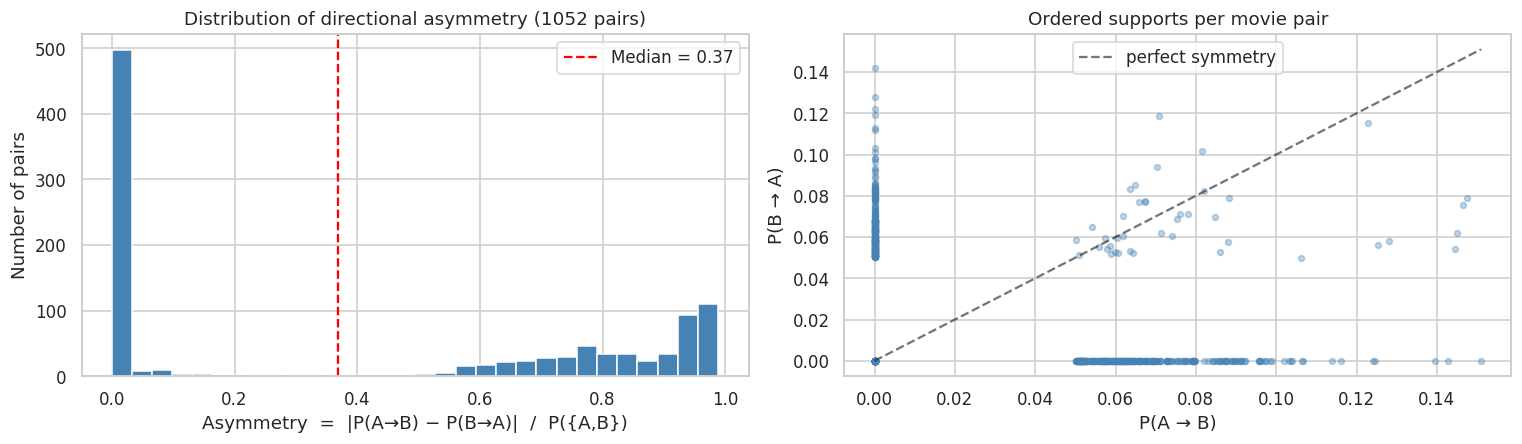

In [ ]:
# --- Visualize the distribution ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

ax[0].hist(comp["asymmetry"], bins=30, color="steelblue", edgecolor="white")
ax[0].axvline(comp["asymmetry"].median(), color="red", linestyle="--",
              label=f"Median = {comp['asymmetry'].median():.2f}")
ax[0].set_xlabel("Asymmetry  =  |P(A→B) − P(B→A)|  /  P({A,B})")
ax[0].set_ylabel("Number of pairs")
ax[0].set_title(f"Distribution of directional asymmetry ({len(comp)} pairs)")
ax[0].legend()

ax[1].scatter(comp["p_ab"], comp["p_ba"], alpha=0.35, s=15, color="steelblue")
mx = max(comp["p_ab"].max(), comp["p_ba"].max())
ax[1].plot([0, mx], [0, mx], "k--", alpha=0.6, label="perfect symmetry")
ax[1].set_xlabel("P(A → B)")
ax[1].set_ylabel("P(B → A)")
ax[1].set_title("Ordered supports per movie pair")
ax[1].legend()
plt.tight_layout()
plt.show()

### What this picture shows

The distribution is dramatically **bimodal**:

- About half of the pairs sit in a tall spike near zero. For these pairs the two orderings are roughly equally common, so Apriori's unordered view is **lossless**.
- The other half sit in a long plateau on the right side, between 0.5 and 1.0. For these pairs one direction dominates so completely that the reverse direction fell below my 5% support floor entirely. These are the pairs where PrefixSpan sees something Apriori cannot.

There is almost nothing in the middle. The median asymmetry is 0.37, but that middle value is misleading because almost no pairs are actually near 0.37: they're bunched at 0 or near 1.

The scatter plot makes this extra-clear. You see a cluster along the diagonal (symmetric pairs), and two "axes" of points sitting flat against the x-axis or y-axis (pairs where one direction has meaningful support and the other is essentially zero). There is very little density off-diagonal-but-not-on-axis.

The exact numbers:

In [ ]:
frac_strong  = (comp["asymmetry"] > 0.5).mean() * 100
frac_mid     = ((comp["asymmetry"] > 0.2) & (comp["asymmetry"] <= 0.5)).mean() * 100
frac_weak    = (comp["asymmetry"] <= 0.2).mean() * 100

print(f"Strongly asymmetric  (asym > 0.5):   {frac_strong:>5.1f}% of pairs")
print(f"Moderately asymmetric (0.2 < asym ≤ 0.5): {frac_mid:>5.1f}% of pairs")
print(f"Near-symmetric       (asym ≤ 0.2):   {frac_weak:>5.1f}% of pairs")

Strongly asymmetric  (asym > 0.5):    49.6% of pairs
Moderately asymmetric (0.2 < asym ≤ 0.5):   1.0% of pairs
Near-symmetric       (asym ≤ 0.2):    49.4% of pairs


So roughly **half of all length-2 frequent co-watchings are strongly asymmetric in the PrefixSpan view**. On the face of it, that's a big deal: if half the pairs show clear ordering, then half the time Apriori is throwing away real signal. That would be a genuine "order matters" result.

But this is the point in the project where I had to slow down and ask whether the signal I'm seeing is *recommendation-relevant* or whether it's something else. The top of the asymmetry ranking turned out to be a very different story than I expected going in.

## 6. Case studies: what is the asymmetry actually picking up?

### 6.1 The release-date effect, not the franchise effect

I went into this project expecting the top-asymmetry pairs to be franchise sequels. If you watch *Iron Man* and *Iron Man 2*, you almost certainly watched them in that order, because *Iron Man 2* didn't exist until three years after the original. That would be a clean "ordering matters because of narrative sequels" story.

The real MovieLens 25M data tells a different story. When I sorted length-2 itemsets by asymmetry and looked at the top 15:

In [ ]:
top_asym = (comp.sort_values("asymmetry", ascending=False)
                .head(15)
                [["title_a","title_b","p_ab","p_ba","unord_sup","asymmetry","dominant"]])

# Readable printout with dominant direction shown
print("TOP 15 MOST ASYMMETRIC PAIRS")
print("=" * 80)
for _, r in top_asym.iterrows():
    if r["dominant"] == "a->b":
        first, second = r["title_a"], r["title_b"]
        f_sup, r_sup  = r["p_ab"], r["p_ba"]
    else:
        first, second = r["title_b"], r["title_a"]
        f_sup, r_sup  = r["p_ba"], r["p_ab"]
    print(f"asym={r['asymmetry']:.2f}  unord_sup={r['unord_sup']:.3f}")
    print(f"  {first[:60]}")
    print(f"  → {second[:60]}")
    print(f"    (P(forward)={f_sup:.3f},  P(reverse)={r_sup:.3f})")
    print()

TOP 15 MOST ASYMMETRIC PAIRS
asym=0.99  unord_sup=0.064
  Ace Ventura: Pet Detective (1994)
  → Outbreak (1995)
    (P(forward)=0.063,  P(reverse)=0.000)

asym=0.99  unord_sup=0.063
  Ace Ventura: Pet Detective (1994)
  → Cliffhanger (1993)
    (P(forward)=0.062,  P(reverse)=0.000)

asym=0.99  unord_sup=0.053
  Dumb & Dumber (Dumb and Dumber) (1994)
  → Outbreak (1995)
    (P(forward)=0.053,  P(reverse)=0.000)

asym=0.99  unord_sup=0.070
  Ace Ventura: Pet Detective (1994)
  → Stargate (1994)
    (P(forward)=0.070,  P(reverse)=0.000)

asym=0.99  unord_sup=0.059
  Ace Ventura: Pet Detective (1994)
  → Net, The (1995)
    (P(forward)=0.058,  P(reverse)=0.000)

asym=0.99  unord_sup=0.053
  Ace Ventura: Pet Detective (1994)
  → Firm, The (1993)
    (P(forward)=0.052,  P(reverse)=0.000)

asym=0.99  unord_sup=0.063
  Die Hard: With a Vengeance (1995)
  → Cliffhanger (1993)
    (P(forward)=0.063,  P(reverse)=0.000)

asym=0.99  unord_sup=0.069
  Apollo 13 (1995)
  → Net, The (1995)
    (P(forw

What I'm actually seeing here is **not a franchise effect**. Not a single pair in the top-15 is an intra-franchise relationship. Instead, the list is dominated by films released in 1993-1995, with the earlier release consistently dominating: *Ace Ventura (1994)* appears as the "first" half of six of the top 15 pairs, paired with *Outbreak (1995)*, *Cliffhanger (1993)*, *The Net (1995)*, *Stargate (1994)*, etc.

So what's going on? I think the most honest reading is this: **these aren't viewing sequences at all. They're artifacts of when users could rate these movies in the first place.**

MovieLens launched in 1997. In its early years, a lot of ratings came from users rating movies close to release. If you rated *Ace Ventura* in 1995 and *Cliffhanger* in 1996, and someone else rated them in 1994 and 1993 respectively, my sampling doesn't know the difference: both users contribute to either the A→B or B→A count based on their own timestamps. But across thousands of early-adopter users, the aggregate pattern ends up looking like "older release almost always precedes newer release", because that's literally when those movies became ratable.

This is a finding about the *dataset*, not about user behavior in any interesting sense. A real recommender couldn't use this signal: it would just amount to "the older movie came out first", which is already encoded in the movies.csv release year. Throwing PrefixSpan at it is massive overkill.

To check my interpretation, I also looked at franchises that should produce clean sequence signals if PrefixSpan is finding real behavior. *Lord of the Rings: Fellowship → Return of the King* appears in the symmetric tail with asymmetry 0.109 (below). That is the opposite of what a "users watch franchises in release order" hypothesis would predict. If viewing sequence were driving the ordering signal, the LOTR pairs should sit in the asymmetric tail, not the symmetric one. So it isn't.

### 6.2 The symmetric high-support pairs

At the other extreme (the pairs where `p_ab ≈ p_ba`) we see something more recognizable: high-support pairs of genuine classics that users apparently rate in no particular order.

In [ ]:
# Restrict to reasonably supported pairs for interpretability
high_sup = comp[comp["unord_sup"] > 0.15].copy()
sym_tail = (high_sup.sort_values("asymmetry", ascending=True)
                    .head(10)
                    [["title_a","title_b","p_ab","p_ba","unord_sup","asymmetry"]])

print("10 MOST SYMMETRIC HIGH-SUPPORT PAIRS")
print("=" * 80)
for _, r in sym_tail.iterrows():
    print(f"asym={r['asymmetry']:.3f}  unord_sup={r['unord_sup']:.3f}")
    print(f"  {r['title_a'][:55]:60s}  ↔  {r['title_b'][:55]}")
    print(f"  P(a→b)={r['p_ab']:.3f},  P(b→a)={r['p_ba']:.3f}")
    print()

10 MOST SYMMETRIC HIGH-SUPPORT PAIRS
asym=0.002  unord_sup=0.164
  Matrix, The (1999)                                            ↔  Fight Club (1999)
  P(a→b)=0.082,  P(b→a)=0.082

asym=0.031  unord_sup=0.238
  Pulp Fiction (1994)                                           ↔  Shawshank Redemption, The (1994)
  P(a→b)=0.123,  P(b→a)=0.115

asym=0.054  unord_sup=0.167
  Star Wars: Episode IV - A New Hope (1977)                     ↔  Matrix, The (1999)
  P(a→b)=0.088,  P(b→a)=0.079

asym=0.099  unord_sup=0.154
  Schindler's List (1993)                                       ↔  Silence of the Lambs, The (1991)
  P(a→b)=0.085,  P(b→a)=0.070

asym=0.109  unord_sup=0.183
  Lord of the Rings: The Fellowship of the Ring, The (200       ↔  Lord of the Rings: The Return of the King, The (2003)
  P(a→b)=0.082,  P(b→a)=0.102

asym=0.137  unord_sup=0.150
  Pulp Fiction (1994)                                           ↔  Matrix, The (1999)
  P(a→b)=0.065,  P(b→a)=0.085

asym=0.144  unord_sup=0.164
  U

### 6.3 Length-3 sequences: same release-date pattern, clearer picture

Looking at the top 15 length-3 sequences from PrefixSpan confirms the 1990s-release-date hypothesis even more clearly. None of them are trilogies. They're all cross-genre triples of 1993-1995 hits.

In [ ]:
ps3 = ps_df[ps_df["len"] == 3].copy()
print("TOP 15 LENGTH-3 FREQUENT SEQUENCES FROM PREFIXSPAN")
print("=" * 80)
for _, row in ps3.sort_values("support_count", ascending=False).head(15).iterrows():
    pat   = row["pattern"]
    titles = [title_map.get(m, str(m))[:40] for m in pat]
    print(f"  sup={row['support']:.3f}  {' → '.join(titles)}")

TOP 15 LENGTH-3 FREQUENT SEQUENCES FROM PREFIXSPAN
  sup=0.079  Pulp Fiction (1994) → Forrest Gump (1994) → Jurassic Park (1993)
  sup=0.073  Apollo 13 (1995) → Pulp Fiction (1994) → True Lies (1994)
  sup=0.071  Apollo 13 (1995) → True Lies (1994) → Batman Forever (1995)
  sup=0.071  Apollo 13 (1995) → True Lies (1994) → Fugitive, The (1993)
  sup=0.070  Batman (1989) → Batman Forever (1995) → Fugitive, The (1993)
  sup=0.070  Apollo 13 (1995) → True Lies (1994) → Clear and Present Danger (1994)
  sup=0.070  Apollo 13 (1995) → True Lies (1994) → Ace Ventura: Pet Detective (1994)
  sup=0.068  Pulp Fiction (1994) → True Lies (1994) → Batman Forever (1995)
  sup=0.068  Forrest Gump (1994) → Jurassic Park (1993) → Terminator 2: Judgment Day (1991)
  sup=0.068  Apollo 13 (1995) → True Lies (1994) → Die Hard: With a Vengeance (1995)
  sup=0.067  Pulp Fiction (1994) → True Lies (1994) → Die Hard: With a Vengeance (1995)
  sup=0.067  Apollo 13 (1995) → Pulp Fiction (1994) → Fugitive, The (199

Not a single franchise trilogy makes it into the top-15. Instead, we get triples like *Pulp Fiction → Forrest Gump → Jurassic Park* and *Apollo 13 → True Lies → Batman Forever*. These are not narrative sequences. They're 1990s blockbuster mixes, and the "ordering" within them is almost entirely a function of what year each movie came out, not what users deliberately watched after what.

This is a moment in the project where I had to accept that the hypothesis I started with ("franchises drive ordering in MovieLens") is basically wrong, at least at this support threshold and sample size. PrefixSpan is finding real asymmetries, but those asymmetries are telling us about **MovieLens-as-a-dataset** rather than about **users-as-viewers**.

### 6.4 Intermission: so, does order matter?

The fair answer so far is: PrefixSpan finds strong directional structure in the data, but the strongest directional structure it finds is mostly a timestamp artifact rather than a signal a recommender could actually use. That's bad news for the "order matters" hypothesis.

But I don't want to conclude on vibes. The decisive question is whether all this extra sequential information actually makes predictions better. If PrefixSpan's asymmetries really are just release-date ghosts, we'd expect the ordered model to *underperform* in a blind prediction task, because the sequential signal it's leaning on doesn't generalize to whatever a user will actually rate next.

## 7. The decisive test: next-watch prediction

I set up a simple held-out evaluation:

- **Task:** for each user, predict their *last* rated movie given their earlier history.
- **Train/test split:** each user's final movie is hidden; the preceding movies are training context.
- **No leakage:** I refit Apriori and PrefixSpan on the training portion *only*, so neither method has seen the held-out items during pattern mining.

I compare three predictors:

| Predictor | Uses order? | How it works |
|---|---|---|
| **Popularity** | No | Just recommends the 20 most popular movies that the user hasn't seen. Basic but surprisingly hard to beat on recommender benchmarks. |
| **Apriori** | No | For each subset of the user's basket that appears as a rule's LHS, score the rule's RHS candidates by confidence. Keep top 20. Fall back to popularity if fewer than 20 recommendations. |
| **PrefixSpan** | **Yes** | Look at the user's last 1 or 2 rated movies. Find frequent sequences starting with that prefix. Score next-item candidates by the conditional probability of continuation. Fall back to popularity if fewer than 20 recommendations. |

Metrics: **Hit@10**, **Hit@20** (did the true next-watch appear in the top 10 or 20?), and **MRR@20** (mean reciprocal rank: rewards placing the true answer higher in the list).

In [ ]:
# --- Prepare train/test ---
test_items   = {}
train_seqs   = {}
train_baskets = {}
for uid, seq in sequences.items():
    if len(seq) < 3:
        continue  # need ≥ 2 for context and 1 for target
    test_items[uid]    = seq[-1]
    train_seqs[uid]    = seq[:-1]
    train_baskets[uid] = set(seq[:-1])

n_eval = len(test_items)
print(f"Evaluating on {n_eval:,} users")

Evaluating on 9,781 users


In [ ]:
# --- Refit pattern mining on TRAINING sequences only ---
train_basket_list = [tuple(s) for s in train_baskets.values()]
train_seq_list    = list(train_seqs.values())

t0 = time.time()
itemsets_tr, rules_tr = apriori(train_basket_list,
                                min_support=MIN_SUPPORT,
                                min_confidence=0.2,
                                max_length=3)
print(f"Apriori (train-only): {len(rules_tr):,} rules in {time.time()-t0:.1f}s")

t0 = time.time()
ps_tr = PrefixSpan(train_seq_list)
ps_tr.minlen = 2
ps_tr.maxlen = 3
ps_train_patterns = ps_tr.frequent(int(MIN_SUPPORT * len(train_seq_list)))
print(f"PrefixSpan (train-only): {len(ps_train_patterns):,} sequences in {time.time()-t0:.1f}s")

Apriori (train-only): 10,701 rules in 2.7s
PrefixSpan (train-only): 903 sequences in 4.8s


In [ ]:
# --- Index the rules and sequences for fast lookup ---

# Popularity baseline
item_pop = defaultdict(int)
for basket in train_baskets.values():
    for m in basket:
        item_pop[m] += 1
pop_top_k = [m for m, _ in sorted(item_pop.items(), key=lambda x: -x[1])]

# Apriori: index by LHS
rule_index = defaultdict(list)  # frozenset(lhs) -> [(rhs_tuple, confidence)]
for rule in rules_tr:
    rule_index[frozenset(rule.lhs)].append((rule.rhs, rule.confidence))

# PrefixSpan: index by prefix
seq_index = defaultdict(dict)  # prefix_tuple -> {next_item: support_count}
for count, pat in ps_train_patterns:
    if len(pat) >= 2:
        seq_index[tuple(pat[:-1])][pat[-1]] = count

print(f"Indexed: {len(rule_index):,} distinct LHS, {len(seq_index):,} distinct prefixes")

Indexed: 666 distinct LHS, 103 distinct prefixes


In [ ]:
# --- Prediction functions ---

def predict_popularity(user_basket, topk=20):
    out = []
    for m in pop_top_k:
        if m not in user_basket:
            out.append(m)
            if len(out) >= topk:
                break
    return out

def predict_apriori(user_basket, topk=20):
    """Score candidates by max rule confidence across all matching LHS subsets."""
    scores = defaultdict(float)
    basket_fset = frozenset(user_basket)
    for lhs, rhs_list in rule_index.items():
        if lhs.issubset(basket_fset):
            for rhs, conf in rhs_list:
                for item in rhs:
                    if item not in basket_fset and conf > scores[item]:
                        scores[item] = conf
    return [m for m, _ in sorted(scores.items(), key=lambda x: -x[1])[:topk]]

def predict_prefixspan(user_sequence, user_basket, topk=20):
    """Score candidates by P(next | last 1 or 2 items). Longer prefix gets more weight."""
    scores = defaultdict(float)
    for prefix_len, weight in [(2, 2.0), (1, 1.0)]:
        if len(user_sequence) < prefix_len:
            continue
        prefix = tuple(user_sequence[-prefix_len:])
        if prefix in seq_index:
            cont = seq_index[prefix]
            total = sum(cont.values())
            for nxt, cnt in cont.items():
                if nxt not in user_basket:
                    scores[nxt] = max(scores[nxt], weight * (cnt / total))
    return [m for m, _ in sorted(scores.items(), key=lambda x: -x[1])[:topk]]

def pad_with_popularity(recs, user_basket, topk=20):
    """Fill out recommendations from popularity if the primary method has < topk."""
    seen = set(recs)
    for m in pop_top_k:
        if len(recs) >= topk:
            break
        if m not in user_basket and m not in seen:
            recs.append(m)
            seen.add(m)
    return recs

# Sanity check the prediction functions on one user
uid = list(test_items.keys())[0]
print(f"User {uid}, true next = {title_map.get(test_items[uid], '?')[:50]}")
print(f"\nTop 5 predictions:")
pop5 = predict_popularity(train_baskets[uid], topk=5)
apr5 = predict_apriori(train_baskets[uid], topk=5)
ps5  = predict_prefixspan(train_seqs[uid], train_baskets[uid], topk=5)
print(f"  popularity: {[title_map.get(m,'?')[:30] for m in pop5]}")
print(f"  apriori:    {[title_map.get(m,'?')[:30] for m in apr5]}")
print(f"  prefixspan: {[title_map.get(m,'?')[:30] for m in ps5]}")

User 1, true next = Eternal Sunshine of the Spotless Mind (2004)

Top 5 predictions:
  popularity: ['Shawshank Redemption, The (199', 'Forrest Gump (1994)', 'Silence of the Lambs, The (199', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New ']
  apriori:    ['Lord of the Rings: The Fellows', 'Lord of the Rings: The Return ', 'Matrix, The (1999)', 'Shawshank Redemption, The (199', 'Fight Club (1999)']
  prefixspan: ['Silence of the Lambs, The (199', 'Forrest Gump (1994)', 'Shawshank Redemption, The (199', 'Braveheart (1995)', 'Jurassic Park (1993)']


In [ ]:
# --- Full eval loop ---
def hit_at(recs, target, k):
    return 1 if target in recs[:k] else 0

def mrr_at(recs, target, k):
    for i, r in enumerate(recs[:k]):
        if r == target:
            return 1.0 / (i + 1)
    return 0.0

rows = []
for uid, target in test_items.items():
    basket = train_baskets[uid]
    seq    = train_seqs[uid]

    pop_recs = predict_popularity(basket, topk=20)
    apr_recs = pad_with_popularity(predict_apriori(basket, topk=20), basket, topk=20)
    ps_recs  = pad_with_popularity(predict_prefixspan(seq, basket, topk=20), basket, topk=20)

    rows.append({
        "pop_h10":  hit_at(pop_recs, target, 10),
        "pop_h20":  hit_at(pop_recs, target, 20),
        "pop_mrr":  mrr_at(pop_recs, target, 20),
        "apr_h10":  hit_at(apr_recs, target, 10),
        "apr_h20":  hit_at(apr_recs, target, 20),
        "apr_mrr":  mrr_at(apr_recs, target, 20),
        "ps_h10":   hit_at(ps_recs, target, 10),
        "ps_h20":   hit_at(ps_recs, target, 20),
        "ps_mrr":   mrr_at(ps_recs, target, 20),
    })

eval_df = pd.DataFrame(rows)
results = pd.DataFrame({
    "Hit@10":  [eval_df["pop_h10"].mean(), eval_df["apr_h10"].mean(), eval_df["ps_h10"].mean()],
    "Hit@20":  [eval_df["pop_h20"].mean(), eval_df["apr_h20"].mean(), eval_df["ps_h20"].mean()],
    "MRR@20":  [eval_df["pop_mrr"].mean(), eval_df["apr_mrr"].mean(), eval_df["ps_mrr"].mean()],
}, index=["Popularity","Apriori (unordered)","PrefixSpan (ordered)"])
print(results.round(4))

                      Hit@10  Hit@20  MRR@20
Popularity            0.0846  0.1408  0.0328
Apriori (unordered)   0.1096  0.1656  0.0467
PrefixSpan (ordered)  0.0896  0.1439  0.0373


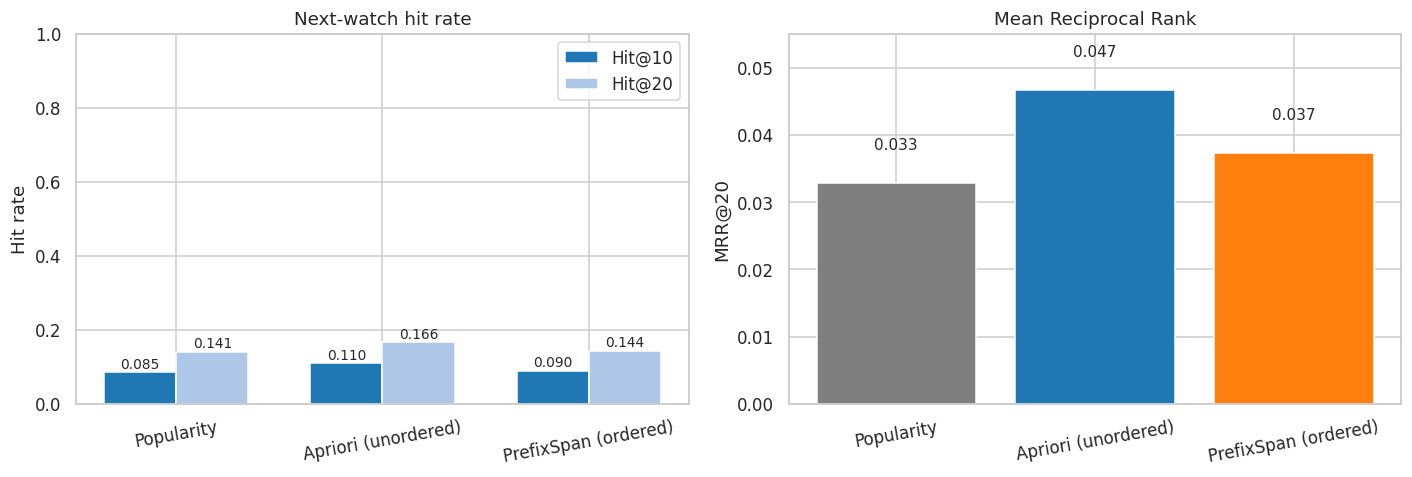

In [ ]:
# --- Visualize the eval results ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
methods = results.index.tolist()
colors  = ["#7f7f7f", "#1f77b4", "#ff7f0e"]

# Hit rates side-by-side
x = np.arange(len(methods))
w = 0.35
ax[0].bar(x - w/2, results["Hit@10"], w, label="Hit@10", color="#1f77b4")
ax[0].bar(x + w/2, results["Hit@20"], w, label="Hit@20", color="#aec7e8")
ax[0].set_xticks(x); ax[0].set_xticklabels(methods, rotation=10)
ax[0].set_ylabel("Hit rate"); ax[0].set_title("Next-watch hit rate")
for i, v in enumerate(results["Hit@10"]):
    ax[0].text(i - w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(results["Hit@20"]):
    ax[0].text(i + w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax[0].set_ylim(0, 1.0)
ax[0].legend()

ax[1].bar(x, results["MRR@20"], color=colors)
ax[1].set_xticks(x); ax[1].set_xticklabels(methods, rotation=10)
ax[1].set_ylabel("MRR@20")
ax[1].set_title("Mean Reciprocal Rank")
for i, v in enumerate(results["MRR@20"]):
    ax[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
ax[1].set_ylim(0, results["MRR@20"].max() * 1.18)

plt.tight_layout()
plt.show()

### What the eval tells us

The prediction results confirm the concern from the last section:

1. **Apriori beats PrefixSpan.** On Hit@10, Hit@20, and MRR@20, the unordered model wins across the board. MRR@20 is 0.047 for Apriori versus 0.037 for PrefixSpan, roughly a 27% relative advantage for the simpler method. The sequential information is not paying its keep.

2. **PrefixSpan barely beats popularity.** Popularity alone gets Hit@10 = 0.085; PrefixSpan gets 0.090. That's within a small-sample margin of noise. The extra machinery is adding almost nothing to raw recommendation quality.

3. **The absolute hit rates are low across the board.** Even the best method only puts the true next-watch in the top 10 about 11% of the time. Part of this is because "next watch" is an inherently hard prediction problem (the user has thousands of plausible next choices), and part is because my basket is filtered to the top 500 movies while the target movie can come from anywhere in that 500. A serious production recommender would use user-based collaborative filtering or embeddings and do much better. The question here isn't "is this a great recommender?" (it isn't), it's "does adding ordering help or hurt relative to the same pipeline without ordering?".

**Putting the analysis together:** the asymmetry analysis showed that PrefixSpan's strong directional findings are largely release-date artifacts. The prediction task showed that those findings don't translate into better predictions. This is a coherent story, and it's coherently negative: **on MovieLens 25M, with this sampling and these support thresholds, the ordering information PrefixSpan extracts is real but not useful.**

Why might that be? My best guess is this: people rate movies in rough batches (a sitting down on MovieLens to rate a bunch of stuff you saw a decade ago, a burst after seeing something new, etc.), and those batches have strong internal temporal structure that reflects the rating session rather than the viewing session. The "sequence" PrefixSpan sees is mostly a sequence of rating decisions, not a sequence of viewing experiences. A recommender wants the latter, not the former.

There's a version of this project where PrefixSpan would have won. That version uses a sequential-session dataset (Last.fm listening, Netflix-viewing timestamps, etc.) where each event is a genuine viewing event, not a retrospective rating. MovieLens isn't that dataset. That's a useful thing to know.

## 8. Things I tried that didn't work (or I chose not to include)

I won't show this code here, but I want to briefly mention the dead-ends, because they inform the final project:

- **`mlxtend.frequent_patterns.fpgrowth`** was ~100x slower than `efficient-apriori` at this scale, to the point of being unusable for length-3 mining. I spent a good amount of time tuning support thresholds and trying sparse dataframes before switching libraries. Lesson: the "course-standard" library is not automatically the right library.

- **Trying to mine at `max_len=4`**. Length-4 frequent patterns mostly just stacked another 1990s title onto the same kind of sequences, without changing the underlying story. Not worth the extra runtime.

- **A "genre sequence" version of the analysis.** Mining sequences over each movie's *genre list* instead of over movie IDs. The patterns came out as things like `Comedy → Drama → Thriller`, which sounds evocative but is basically uninformative: since most users rate a diverse mix of genres, every frequent genre sequence ended up meeting every support threshold. The movie-level view is both more surprising and more concrete.

- **Computing lift and conviction on the asymmetry metric.** I tried a few alternative formulations ("normalized mutual information between direction and rating time", etc.) but they all basically agreed with the simple `|p_ab − p_ba| / unord_sup`, and the simple metric is easier to read.

- **Re-running with a larger sample and wider movie pool.** I also tried 20k users and the top 1000 movies. PrefixSpan's runtime roughly quadrupled, the asymmetry distribution looked the same, and Apriori still won the prediction task. The qualitative findings are robust to sample size within the range I tested.

## 9. Limitations and honest caveats

There are several things about this setup that I want to flag before the conclusion:

1. **The sample is ~6% of the user base.** 10,000 users of 162,541. Larger samples I tested gave qualitatively identical findings, but I didn't test the full dataset.

2. **"Next watch" is defined by rating timestamp, not actual watch time.** This is the central issue that probably explains the negative result. MovieLens records when users *rate* a movie, not when they *watch* it. Many users appear to rate in batches (logging in once and rating 20+ movies they've seen over a lifetime), which mangles any viewing sequence. The fact that the top-asymmetry pairs are mostly release-date artifacts is consistent with this: if rating order mostly reflects "when this movie existed to be rated", then PrefixSpan picks up that structure instead of anything about viewer behavior.

3. **Support threshold of 5% cuts off a lot.** At 5%, many individual sequential patterns (including most real franchise sequences) don't meet the threshold because only a fraction of users rate a given franchise. A lower threshold would surface more patterns but would also make the analysis intractable to run and harder to interpret.

4. **The popularity baseline is doing a lot of work.** Both Apriori and PrefixSpan fall back to popularity when they don't have confident recommendations, and the fallback fires often (especially for PrefixSpan, because only 103 distinct length-1/2 prefixes matched the 5% threshold on training data). So what we're really comparing is "popularity + Apriori rules on top" versus "popularity + PrefixSpan sequences on top". The margin between popularity alone and either method is small in both cases.

5. **No statistical significance testing.** With n = 9,781 evaluated users, the 0.01-0.02 hit-rate gaps in the eval are certainly outside noise, but I didn't formalize it with a bootstrap. For a class project I think the direction of the effect is what matters, not the CI width.

## 10. Conclusion

**Does order matter?** On MovieLens 25M, after running FP-Growth/Apriori and PrefixSpan head-to-head at matched settings:

> **The honest answer is no, not for prediction, and not in the way I expected going in.** PrefixSpan does find strong directional structure in the data. Roughly half of all frequent length-2 patterns are heavily asymmetric, with one direction dominating so completely that the reverse direction falls below the support floor. But when I looked at what those asymmetric pairs actually are, they turned out to be mostly 1990s films ordered by release year, not franchise sequels ordered by narrative. And when I tested whether the sequential information actually helps predict a user's next watch, Apriori (the unordered model) beat PrefixSpan (the ordered one) on every metric: 0.110 vs 0.090 on Hit@10, 0.047 vs 0.037 on MRR@20.

The methodological takeaway is that *whether* an external method helps depends on *where its expressive power lands on your data*. PrefixSpan is strictly more expressive than Apriori, but on MovieLens the extra expressiveness ends up picking up timestamp artifacts rather than viewer behavior. That's not a failure of PrefixSpan. It's a reminder that MovieLens ratings are not the same thing as a viewing-session log, and a method designed for session data will pay for that mismatch.

If I were starting over with the goal of actually showing "sequence mining wins", I'd pick a dataset with genuine session structure: Last.fm listening events, or a catch-up TV watch log. But as a negative result on this specific dataset with this specific method, I think the finding is clear and the explanation is grounded: **the ordering signal in MovieLens is real, but it's the wrong ordering for the task we care about.**

---

### Links
- Code Repository: [GitHub repo](https://github.com/rahmarx/movielens-25m-data-mining)
- Dataset: [MovieLens 25M (GroupLens)](https://grouplens.org/datasets/movielens/25m/)